# Pipeline final OGLE + VVV — Lomb–Scargle para todas, Mínima Entropía como cross-check

**Esquema**

| Catálogo | # estrellas | Lomb–Scargle | Mínima Entropía (subset top-power) |
|----------|-------------|--------------|-------------------------------------|
| OGLE     | 50          | 50           | 10                                  |
| VVV      | 50 (N_obs≥30)| 50          | 20                                  |

El criterio del subset es **mayor potencia LS** porque queremos cross-checkear las
detecciones más confiables (alta potencia ⇒ candidato periódico fuerte; si MinEnt confirma,
el periodo es muy creíble; si discrepa, probable alias armónico o 1-day alias).

**Entrega**
1. DataFrame final unificado (`resultados_finales.csv`) con periodo LS para las 100 estrellas
   y columnas extra con MinEnt + métricas de acuerdo para el subset.
2. Figuras individuales: 100 con LS-only (4 paneles), 30 con LS+ME comparados (5 paneles).
3. Figuras globales: distribuciones LS, Periodo–Amplitud, calidad LS, scatter `P_LS` vs `P_ME` del subset.
4. Insights con números reales del cómputo + roadmap.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.timeseries import LombScargle

# --- Paleta consistente ---
PRIMARY   = "#870047"
SECONDARY = "#ff6aa7"
DARK      = "#3a0020"
LIGHT     = "#ffc2da"
MUTED     = "#7a5060"
INK       = "#1a1014"

from matplotlib.colors import LinearSegmentedColormap
CMAP = LinearSegmentedColormap.from_list("pink_palette", [LIGHT, PRIMARY, DARK])

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": LIGHT, "axes.grid": True, "grid.alpha": 0.4,
    "axes.prop_cycle": __import__("matplotlib").cycler(color=[PRIMARY, SECONDARY, DARK, MUTED]),
})

# --- Configuración ---
OGLE_PATH = Path("singlemode_variable_stars_sample.h5")
VVV_PATH  = Path("VVV_Sample.fits")
OUTDIR = Path("resultados_finales"); OUTDIR.mkdir(exist_ok=True)
INDIV_LS_DIR = OUTDIR / "individuales_LS"; INDIV_LS_DIR.mkdir(exist_ok=True)
INDIV_BOTH_DIR = OUTDIR / "individuales_comparacion"; INDIV_BOTH_DIR.mkdir(exist_ok=True)

N_OGLE       = 50
N_VVV        = 50
MIN_N_OBS_VVV = 30
N_OGLE_ME    = 10   # subset top-LS-power para correr MinEnt en OGLE
N_VVV_ME     = 20   # subset top-LS-power para correr MinEnt en VVV

P_MIN, P_MAX = 0.1, 10.0

# --- Hiperparámetros MinEnt v2: conditional entropy + grilla adaptativa + alias mask ---
N_PHASE_BINS_ME     = 20             # más bins de fase → mejor resolución del plegado
N_MAG_BINS_ME       = 20             # más bins de mag → mata el atractor a P=1d
SAMPLES_PER_PEAK_ME = 5              # densidad relativa a 1/T_baseline (resolución física)
ALIAS_FORBIDDEN     = (1.0, 0.5, 1.0/3, 2.0, 1.0/2)   # aliases diurnos a enmascarar
ALIAS_REL_TOL       = 0.005          # ±0.5% alrededor de cada alias

SAMPLES_PER_PEAK = 10
N_PHASE_BINS_FOLD = 25
AGREEMENT_TOL = 0.01
HARMONIC_TOL  = 0.02


## 1. Utilidades (limpieza, métodos, métricas)

In [2]:
def clean_lightcurve(t, mag, err=None, min_points=20):
    t = np.asarray(t, dtype=float).ravel()
    mag = np.asarray(mag, dtype=float).ravel()
    if err is None:
        err = np.full_like(mag, np.nan, dtype=float)
    else:
        err = np.asarray(err, dtype=float).ravel()
    n = min(len(t), len(mag), len(err))
    t, mag, err = t[:n], mag[:n], err[:n]
    mask = np.isfinite(t) & np.isfinite(mag)
    t, mag, err = t[mask], mag[mask], err[mask]
    if len(t) < min_points:
        return None, None, None
    order = np.argsort(t)
    t, mag, err = t[order], mag[order], err[order]
    if np.isfinite(err).sum() == 0:
        err = None
    else:
        err[~np.isfinite(err)] = np.nan
        err[err <= 0] = np.nan
        if np.isnan(err).all():
            err = None
        else:
            med = np.nanmedian(err)
            err = np.where(np.isnan(err), med, err)
    return t, mag, err


# === MinEnt v2: Conditional Entropy ===

def conditional_entropy_phased(t, mag_n, period, n_phase_bins, n_mag_bins):
    """Conditional entropy H(mag | phase). Robusta al alias diurno: en P=1d
    el histograma joint puede ser bajo (columnas estrechas) pero H(mag|phase)
    sigue siendo alto porque hay dispersión real entre noches en cada fase.

    mag_n debe estar pre-normalizado a [0, 1]."""
    phase = np.mod(t / period, 1.0)
    H2d, _, _ = np.histogram2d(phase, mag_n, bins=[n_phase_bins, n_mag_bins],
                                range=[[0.0, 1.0], [0.0, 1.0]])
    total = H2d.sum()
    if total == 0:
        return np.inf
    p_joint = H2d / total
    p_phase = p_joint.sum(axis=1, keepdims=True)        # marginal en fase
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(p_phase > 0, p_joint / p_phase, 0.0)
        log_ratio = np.log(np.where(ratio > 0, ratio, 1.0))
        terms = np.where(p_joint > 0, p_joint * log_ratio, 0.0)
    return float(-terms.sum())


def normalize_mag(mag):
    """Whitening robusto: (mag − mediana) / (3·IQR), recortado a [0, 1]."""
    med = np.median(mag)
    iqr = np.subtract(*np.percentile(mag, [75, 25]))
    if iqr <= 0:
        iqr = np.std(mag) or 1.0
    return np.clip((mag - med) / (3.0 * iqr) + 0.5, 0.0, 1.0)


def alias_keep_mask(periods, forbidden=ALIAS_FORBIDDEN, rel_tol=ALIAS_REL_TOL):
    """True donde el periodo NO está cerca de un alias diurno."""
    bad = np.zeros_like(periods, dtype=bool)
    for P0 in forbidden:
        bad |= np.abs(periods - P0) / P0 < rel_tol
    return ~bad


def minimum_entropy_period(t, mag, p_min=P_MIN, p_max=P_MAX,
                            n_phase_bins=N_PHASE_BINS_ME,
                            n_mag_bins=N_MAG_BINS_ME,
                            samples_per_peak=SAMPLES_PER_PEAK_ME):
    """MinEnt v2: conditional entropy + mag normalizado + grilla adaptativa +
    mascarado explícito de aliases diurnos."""
    T = float(np.ptp(t))
    if T <= 0:
        return {"period": np.nan, "entropy": np.inf,
                "periods": np.array([]), "entropies": np.array([])}

    # Grilla uniforme en frecuencia, paso = 1 / (samples_per_peak · T)
    df = 1.0 / max(samples_per_peak * T, 1e-6)
    freqs = np.arange(1.0 / p_max, 1.0 / p_min + df, df)
    periods = 1.0 / freqs

    # Mascarar aliases diurnos antes del cómputo (ahorra trabajo + evita decantar)
    keep = alias_keep_mask(periods)
    periods = periods[keep]
    if periods.size == 0:
        return {"period": np.nan, "entropy": np.inf,
                "periods": np.array([]), "entropies": np.array([])}

    # Normalizar mag UNA vez (no depende del periodo)
    mag_n = normalize_mag(mag)

    H = np.empty_like(periods)
    for k, P in enumerate(periods):
        H[k] = conditional_entropy_phased(t, mag_n, P, n_phase_bins, n_mag_bins)

    bi = int(np.argmin(H))
    return {"period": float(periods[bi]), "entropy": float(H[bi]),
            "periods": periods, "entropies": H}


def lomb_scargle_period(t, mag, err, p_min=P_MIN, p_max=P_MAX,
                         samples_per_peak=SAMPLES_PER_PEAK):
    use_err = err is not None and np.all(np.isfinite(err)) and np.all(err > 0)
    ls = LombScargle(t, mag, dy=err) if use_err else LombScargle(t, mag)
    f, p = ls.autopower(minimum_frequency=1.0/p_max, maximum_frequency=1.0/p_min,
                        samples_per_peak=samples_per_peak)
    bi = int(np.argmax(p))
    try:
        fap = float(ls.false_alarm_probability(p[bi]))
    except Exception:
        fap = np.nan
    return {"period": 1.0/float(f[bi]), "power": float(p[bi]), "fap": fap,
            "frequency": f, "power_spectrum": p}


def string_length(t, mag, period):
    if period <= 0:
        return np.inf
    phase = np.mod(t/period, 1.0)
    order = np.argsort(phase)
    ph, mg = phase[order], mag[order]
    dphi = np.diff(np.concatenate([ph, [ph[0] + 1.0]]))
    dmag = np.diff(np.concatenate([mg, [mg[0]]]))
    sl = np.sum(np.sqrt(dphi**2 + dmag**2))
    span = np.ptp(mag)
    return float(sl/span) if span > 0 else float(sl)


def phase_coverage(t, period, n_bins=20):
    phase = np.mod(t/period, 1.0)
    h, _ = np.histogram(phase, bins=n_bins, range=(0, 1))
    return float((h > 0).sum() / n_bins)


def binned_median(phase, mag, n_bins=N_PHASE_BINS_FOLD):
    edges = np.linspace(0, 1, n_bins+1)
    centers = 0.5*(edges[:-1] + edges[1:])
    med = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (phase >= edges[i]) & (phase < edges[i+1])
        if m.any():
            med[i] = np.median(mag[m])
    return centers, med


def amplitude_robust(mag, q_lo=0.05, q_hi=0.95):
    return float(np.quantile(mag, q_hi) - np.quantile(mag, q_lo))


def harmonic_match(p_ls, p_me, tol=HARMONIC_TOL):
    if p_me <= 0 or not np.isfinite(p_me) or not np.isfinite(p_ls):
        return ""
    ratio = p_ls/p_me
    candidates = {1.0: "≈ P_ME", 2.0: "≈ 2·P_ME", 0.5: "≈ P_ME/2",
                  3.0: "≈ 3·P_ME", 1/3: "≈ P_ME/3"}
    for k, label in candidates.items():
        if abs(ratio - k)/k < tol:
            return label
    return "sin armónico simple"


## 2. Carga OGLE (50 estrellas)

In [3]:
ogle_curves = []
with h5py.File(OGLE_PATH, "r") as f:
    star_codes = list(f["/"].keys())[:N_OGLE]
    for name in star_codes:
        d = pd.DataFrame(f[name][:])
        t, m, e = clean_lightcurve(
            d["RHJD"].to_numpy(), d["mag"].to_numpy(),
            d["mag_err"].to_numpy() if "mag_err" in d.columns else None,
        )
        if t is None: continue
        ogle_curves.append({
            "survey": "OGLE", "name": f"OGLE_{name}",
            "time": t, "mag": m, "err": e,
            "time_label": "RHJD", "mag_label": "Magnitud I",
        })
print(f"OGLE: {len(ogle_curves)} curvas cargadas")

OGLE: 50 curvas cargadas


## 3. Carga VVV (50 estrellas con N_obs(Ks) ≥ 30)

In [4]:
def stringify_id(x, fallback):
    try:
        arr = np.asarray(x).ravel()
        value = arr[0] if len(arr) else fallback
    except Exception:
        value = x
    if isinstance(value, bytes):
        return value.decode(errors="ignore")
    try:
        if np.isfinite(value) and float(value).is_integer():
            return str(int(value))
    except Exception:
        pass
    return str(value)

vvv_curves = []
with fits.open(VVV_PATH) as hdul:
    blocks = [
        ("b278", hdul[1].data, hdul[2].data, hdul[5].data, hdul[8].data),
        ("b279", hdul[11].data, hdul[12].data, hdul[15].data, hdul[18].data),
    ]
    for tile, id_arr, mag_arr, err_arr, mjd_arr in blocks:
        for i in range(min(len(id_arr), len(mag_arr), len(err_arr), len(mjd_arr))):
            t, m, e = clean_lightcurve(mjd_arr[i], mag_arr[i], err_arr[i],
                                       min_points=MIN_N_OBS_VVV)
            if t is None: continue
            sid = stringify_id(id_arr[i], i)
            vvv_curves.append({
                "survey": "VVV", "name": f"VVV_{tile}_{sid}",
                "time": t, "mag": m, "err": e,
                "time_label": "MJD", "mag_label": "Magnitud Ks",
                "tile": tile,
            })
vvv_curves = vvv_curves[:N_VVV]
print(f"VVV: {len(vvv_curves)} curvas cargadas (N_obs≥{MIN_N_OBS_VVV})")

VVV: 50 curvas cargadas (N_obs≥30)


## 4. Lomb–Scargle para las 100 estrellas

In [5]:
all_curves = ogle_curves + vvv_curves

for c in all_curves:
    out = lomb_scargle_period(c["time"], c["mag"], c["err"])
    c["period_ls"]  = out["period"]
    c["power_ls"]   = out["power"]
    c["fap_ls"]     = out["fap"]
    c["freq_ls"]    = out["frequency"]
    c["pspec_ls"]   = out["power_spectrum"]
    c["sl_ls"]      = string_length(c["time"], c["mag"], out["period"])
    c["cov_ls"]     = phase_coverage(c["time"], out["period"])
    c["amplitude"]  = amplitude_robust(c["mag"])
    c["baseline_d"] = float(np.ptp(c["time"]))
    c["n_obs"]      = int(len(c["time"]))
    c["mag_median"] = float(np.median(c["mag"]))

print("LS calculado para las 100 estrellas")

LS calculado para las 100 estrellas


## 5. Selección del subset por mayor potencia LS y cómputo MinEnt

Top 10 OGLE + top 20 VVV ordenadas por `power_ls` descendente.

In [6]:
def select_top_power(curves, survey, n_top):
    sub = [c for c in curves if c["survey"] == survey]
    sub_sorted = sorted(sub, key=lambda c: c["power_ls"], reverse=True)
    selected_names = {c["name"] for c in sub_sorted[:n_top]}
    return selected_names

selected_ogle = select_top_power(all_curves, "OGLE", N_OGLE_ME)
selected_vvv  = select_top_power(all_curves, "VVV",  N_VVV_ME)
selected = selected_ogle | selected_vvv

for c in all_curves:
    c["has_minent"] = c["name"] in selected

print(f"Subset MinEnt: {len(selected_ogle)} OGLE + {len(selected_vvv)} VVV = {len(selected)} estrellas")
print("\nTop OGLE seleccionadas (por power_ls):")
for c in sorted([c for c in all_curves if c["name"] in selected_ogle],
                key=lambda c: c["power_ls"], reverse=True):
    print(f"  {c['name']:>14}  power={c['power_ls']:.3f}  P_LS={c['period_ls']:.5f}d")
print("\nTop VVV seleccionadas (por power_ls):")
for c in sorted([c for c in all_curves if c["name"] in selected_vvv],
                key=lambda c: c["power_ls"], reverse=True):
    print(f"  {c['name']:>26}  power={c['power_ls']:.3f}  P_LS={c['period_ls']:.5f}d")

Subset MinEnt: 10 OGLE + 20 VVV = 30 estrellas

Top OGLE seleccionadas (por power_ls):
         OGLE_16  power=0.988  P_LS=0.10033d
         OGLE_2d  power=0.987  P_LS=2.55655d
         OGLE_26  power=0.979  P_LS=0.29886d
         OGLE_25  power=0.975  P_LS=1.88867d
         OGLE_29  power=0.972  P_LS=0.26178d
         OGLE_2c  power=0.968  P_LS=0.22000d
         OGLE_20  power=0.964  P_LS=1.56522d
         OGLE_02  power=0.962  P_LS=0.10300d
         OGLE_12  power=0.955  P_LS=1.97441d
         OGLE_2f  power=0.955  P_LS=0.27537d

Top VVV seleccionadas (por power_ls):
     VVV_b278_13685773009175  power=0.890  P_LS=0.18135d
     VVV_b278_13612046006196  power=0.829  P_LS=0.17724d
     VVV_b278_13677578006095  power=0.806  P_LS=0.24452d
     VVV_b278_13612043009408  power=0.785  P_LS=1.99971d
     VVV_b278_13632521004540  power=0.726  P_LS=0.47402d
     VVV_b278_13685765002625  power=0.711  P_LS=0.63166d
     VVV_b278_13657105000896  power=0.708  P_LS=1.64418d
     VVV_b278_13624335012

In [7]:
for i, c in enumerate([cc for cc in all_curves if cc["has_minent"]]):
    out = minimum_entropy_period(c["time"], c["mag"])
    c["period_me"]    = out["period"]
    c["entropy_me"]   = out["entropy"]
    c["periods_grid_me"] = out["periods"]
    c["entropies_grid_me"] = out["entropies"]
    c["sl_me"]        = string_length(c["time"], c["mag"], out["period"])
    c["cov_me"]       = phase_coverage(c["time"], out["period"])
    c["dP"]           = c["period_ls"] - out["period"]
    c["dP_rel"]       = c["dP"] / out["period"] if out["period"] != 0 else np.nan
    c["agree"]        = abs(c["dP_rel"]) < AGREEMENT_TOL
    c["harmonic"]     = harmonic_match(c["period_ls"], out["period"])
    print(f"  [{i+1:02d}/{len(selected):02d}] {c['name']:>26}  P_LS={c['period_ls']:.5f}  P_ME={out['period']:.5f}  ΔP/P={c['dP_rel']:+.2e}  {c['harmonic']}")

# rellenar columnas MinEnt vacías para las que no se calcularon
for c in all_curves:
    if not c["has_minent"]:
        for k in ["period_me","entropy_me","sl_me","cov_me","dP","dP_rel"]:
            c[k] = np.nan
        c["agree"] = False
        c["harmonic"] = ""
print("\nMinEnt completado en el subset.")

  [01/30]                    OGLE_02  P_LS=0.10300  P_ME=0.10300  ΔP/P=+5.96e-14  ≈ P_ME


  [02/30]                    OGLE_12  P_LS=1.97441  P_ME=1.97424  ΔP/P=+8.79e-05  ≈ P_ME


  [03/30]                    OGLE_16  P_LS=0.10033  P_ME=0.10033  ΔP/P=+5.10e-06  ≈ P_ME


  [04/30]                    OGLE_20  P_LS=1.56522  P_ME=1.56522  ΔP/P=-5.01e-14  ≈ P_ME


  [05/30]                    OGLE_25  P_LS=1.88867  P_ME=1.88867  ΔP/P=+3.62e-14  ≈ P_ME


...

  [26/30]    VVV_b278_13607948001363  P_LS=1.74794  P_ME=1.74804  ΔP/P=-5.35e-05  ≈ P_ME


  [27/30]    VVV_b278_13612043009408  P_LS=1.99971  P_ME=3.99914  ΔP/P=-5.00e-01  ≈ P_ME/2


  [28/30]    VVV_b278_13685765002625  P_LS=0.63166  P_ME=0.63167  ΔP/P=-1.93e-05  ≈ P_ME


  [29/30]    VVV_b278_13685773009175  P_LS=0.18135  P_ME=0.18135  ΔP/P=-1.07e-13  ≈ P_ME


  [30/30]    VVV_b278_13632521007598  P_LS=0.53270  P_ME=0.53269  ΔP/P=+1.63e-05  ≈ P_ME

MinEnt completado en el subset.


## 6. DataFrame final

In [8]:
cols = ["name","survey","n_obs","baseline_d","mag_median","amplitude",
        "period_ls","power_ls","fap_ls","sl_ls","cov_ls",
        "has_minent","period_me","entropy_me","sl_me","cov_me",
        "dP","dP_rel","agree","harmonic"]
df = pd.DataFrame([{k: c.get(k) for k in cols} for c in all_curves])
df.to_csv(OUTDIR / "resultados_finales.csv", index=False)
print("Shape:", df.shape)
df.head(10)

Shape: (100, 20)


,name,survey,n_obs,baseline_d,mag_median,amplitude,period_ls,power_ls,fap_ls,sl_ls,cov_ls,has_minent,period_me,entropy_me,sl_me,cov_me,dP,dP_rel,agree,harmonic
0,OGLE_00,OGLE,665,2246.80687,14.0520,0.21500,4.717401,0.942573,0.000000e+00,24.104610,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
1,OGLE_01,OGLE,499,2246.94368,16.6200,0.45010,1.833500,0.718798,6.891017e-133,17.461878,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
2,OGLE_02,OGLE,220,3603.88547,17.5000,0.22435,0.102998,0.962091,1.964666e-150,16.933099,1.0,True,0.102998,1.232816,16.933099,1.0,6.133982e-15,5.955460e-14,True,≈ P_ME
3,OGLE_03,OGLE,110,684.12108,14.8295,0.61905,0.523184,0.685587,4.849030e-24,5.632695,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
4,OGLE_04,OGLE,268,2021.76835,17.3425,0.26330,0.305284,0.929930,3.317394e-149,19.832559,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
5,OGLE_05,OGLE,482,2246.82342,18.8400,0.57985,0.531656,0.686668,5.160329e-117,40.603976,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
6,OGLE_06,OGLE,2000,2714.77692,17.6280,0.26000,0.273522,0.904502,0.000000e+00,132.963525,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
7,OGLE_07,OGLE,234,5193.84805,16.3730,0.06870,4.634117,0.167176,2.276524e-06,35.039102,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
8,OGLE_08,OGLE,131,3121.76255,15.3500,0.18900,3.466021,0.352089,1.655297e-09,24.873548,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,
9,OGLE_09,OGLE,5680,5025.56385,19.4410,0.31505,2.026718,0.070626,1.002368e-85,703.948742,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,False,


## 7. Figuras individuales – LS para las 100 (4 paneles)

In [9]:
def plot_star_ls(c, outdir=INDIV_LS_DIR):
    t, mag = c["time"], c["mag"]
    P = c["period_ls"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.0))

    ax = axes[0]
    ax.scatter(t, mag, s=5, alpha=0.7, color=PRIMARY)
    ax.invert_yaxis()
    ax.set_xlabel(c["time_label"]); ax.set_ylabel(c["mag_label"])
    ax.set_title("Curva de luz observada", fontsize=10)
    ax.text(0.02, 0.97, f"N={c['n_obs']}\nΔt={c['baseline_d']:.1f} d\nA={c['amplitude']:.2f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=MUTED, alpha=0.85))

    ax = axes[1]
    ax.plot(c["freq_ls"], c["pspec_ls"], color=PRIMARY, lw=0.7)
    ax.axvline(1.0/P, color=DARK, ls="--", lw=1.0)
    ax.set_xlabel("Frecuencia [1/d]"); ax.set_ylabel("Potencia LS")
    ax.set_title(f"Lomb–Scargle: P = {P:.6f} d", fontsize=10)
    fap_txt = f"{c['fap_ls']:.2e}" if np.isfinite(c['fap_ls']) else "n/a"
    ax.text(0.02, 0.97, f"power={c['power_ls']:.3f}\nFAP={fap_txt}\ncov={c['cov_ls']:.2f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=SECONDARY, alpha=0.85))

    ax = axes[2]
    phase = np.mod(t/P, 1.0)
    sc = ax.scatter(phase, mag, c=t, cmap=CMAP, s=8, alpha=0.8)
    ax.scatter(phase+1, mag, c=t, cmap=CMAP, s=8, alpha=0.45)
    ph_c, mg_med = binned_median(phase, mag)
    ok = np.isfinite(mg_med)
    ax.plot(ph_c[ok], mg_med[ok], color=MUTED, lw=1.8, label="mediana binada")
    ax.plot(ph_c[ok]+1, mg_med[ok], color=MUTED, lw=1.8, alpha=0.6)
    ax.invert_yaxis()
    ax.set_xlabel("Fase"); ax.set_ylabel(c["mag_label"])
    ax.set_title(f"Curva plegada (2 ciclos)\nSL={c['sl_ls']:.3f}  cov={c['cov_ls']:.2f}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cb.ax.tick_params(labelsize=6); cb.set_label("tiempo", fontsize=7)

    ax = axes[3]
    ax.hist(phase, bins=N_PHASE_BINS_FOLD, range=(0,1), color=PRIMARY, alpha=0.6)
    ax.set_xlabel("Fase"); ax.set_ylabel("# observaciones")
    ax.set_title("Histograma de fase", fontsize=10)

    has_me = c.get("has_minent", False)
    badge = " [+ MinEnt]" if has_me else ""
    fig.suptitle(
        f"{c['name']}  |  {c['survey']}  |  LS{badge}  |  "
        f"P = {P:.6f} d  |  A = {c['amplitude']:.2f}  |  N = {c['n_obs']}",
        fontsize=12, color=PRIMARY,
    )
    fig.tight_layout(rect=[0,0,1,0.93])
    safe = c["name"].replace("/","_").replace(" ","_")
    fig.savefig(outdir/f"{safe}.png", dpi=160, bbox_inches="tight")
    plt.close(fig)

for c in all_curves:
    plot_star_ls(c)
print(f"Generadas {len(list(INDIV_LS_DIR.glob('*.png')))} figuras LS individuales en {INDIV_LS_DIR}")

Generadas 100 figuras LS individuales en resultados_finales/individuales_LS


## 8. Figuras de comparación LS vs ME para el subset (5 paneles)

In [10]:
def plot_star_comparison(c, outdir=INDIV_BOTH_DIR):
    t, mag = c["time"], c["mag"]
    P_LS, P_ME = c["period_ls"], c["period_me"]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4.0))

    # Panel 1: raw
    ax = axes[0]
    ax.scatter(t, mag, s=4, alpha=0.7, color=DARK)
    ax.invert_yaxis()
    ax.set_xlabel(c["time_label"]); ax.set_ylabel(c["mag_label"])
    ax.set_title("Curva de luz observada", fontsize=10)
    ax.text(0.02, 0.97, f"N={c['n_obs']}\nΔt={c['baseline_d']:.1f} d",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=MUTED, alpha=0.85))

    # Panel 2: LS periodogram
    ax = axes[1]
    ax.plot(c["freq_ls"], c["pspec_ls"], color=DARK, lw=0.7)
    ax.axvline(1.0/P_LS, color=SECONDARY, lw=1.2, label=f"P_LS = {P_LS:.5f}")
    ax.axvline(1.0/P_ME, color=PRIMARY, lw=1.0, ls=":", label=f"P_ME = {P_ME:.5f}")
    ax.set_xlabel("Frecuencia [1/d]"); ax.set_ylabel("Potencia LS")
    ax.set_title(f"Lomb–Scargle\nP_LS = {P_LS:.6f}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    fap_txt = f"{c['fap_ls']:.2e}" if np.isfinite(c['fap_ls']) else "n/a"
    ax.text(0.02, 0.97, f"power={c['power_ls']:.3f}\nFAP={fap_txt}\ncov={c['cov_ls']:.2f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=SECONDARY, alpha=0.85))

    # Panel 3: entropy spectrum (zoom)
    ax = axes[2]
    P_grid = c["periods_grid_me"]; H_grid = c["entropies_grid_me"]
    half = max(0.05*P_ME, (P_grid.max()-P_grid.min())*0.02)
    mask = (P_grid > P_ME-half) & (P_grid < P_ME+half)
    if mask.sum() < 50:
        mask = np.ones_like(P_grid, dtype=bool)
    ax.plot(P_grid[mask], H_grid[mask], color=DARK, lw=0.8)
    ax.axvline(P_ME, color=PRIMARY, lw=1.2, label=f"P_ME = {P_ME:.5f}")
    if P_grid[mask].min() < P_LS < P_grid[mask].max():
        ax.axvline(P_LS, color=SECONDARY, lw=1.0, ls=":", label=f"P_LS = {P_LS:.5f}")
    ax.invert_yaxis()
    ax.set_xlabel("Periodo [d]"); ax.set_ylabel("Entropía (eje invertido)")
    ax.set_title(f"Mínima Entropía\nP_ME = {P_ME:.6f}", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    ax.text(0.02, 0.97, f"H_min={c['entropy_me']:.3f}\nSL_ME={c['sl_me']:.3f}\ncov={c['cov_me']:.2f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", ec=PRIMARY, alpha=0.85))

    # Panels 4, 5: folded LS y ME
    for ax, P, label, panel_color, sl_val in [
        (axes[3], P_LS, "LS", SECONDARY, c["sl_ls"]),
        (axes[4], P_ME, "ME", PRIMARY,   c["sl_me"]),
    ]:
        phase = np.mod(t/P, 1.0)
        sc = ax.scatter(phase, mag, c=t, cmap=CMAP, s=6, alpha=0.75)
        ax.scatter(phase+1, mag, c=t, cmap=CMAP, s=6, alpha=0.4)
        ph_c, mg_med = binned_median(phase, mag, N_PHASE_BINS_FOLD)
        ok = np.isfinite(mg_med)
        ax.plot(ph_c[ok], mg_med[ok], color=MUTED, lw=1.6, label="mediana binada")
        ax.plot(ph_c[ok]+1, mg_med[ok], color=MUTED, lw=1.6, alpha=0.6)
        ax.invert_yaxis()
        ax.set_xlabel("Fase"); ax.set_ylabel(c["mag_label"])
        ax.set_title(f"Curva plegada {label}\nP = {P:.6f}", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")
        ax.text(0.02, 0.97, f"SL={sl_val:.3f}", transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec=panel_color, alpha=0.85))
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
        cb.ax.tick_params(labelsize=6); cb.set_label("tiempo", fontsize=7)

    flag = "AGREE" if c["agree"] else "DIFFER"
    flag_color = PRIMARY if c["agree"] else DARK
    fig.suptitle(
        f"{c['name']}  |  {c['survey']}  |  ΔP = {c['dP']:+.6e}  |  "
        f"ΔP/P = {c['dP_rel']:+.3e}  |  [{flag}]  |  armónico: {c['harmonic']}",
        fontsize=12, color=flag_color,
    )
    fig.tight_layout(rect=[0,0,1,0.93])
    safe = c["name"].replace("/","_").replace(" ","_")
    fig.savefig(outdir/f"{safe}_comparacion.png", dpi=170, bbox_inches="tight")
    plt.close(fig)

for c in [cc for cc in all_curves if cc["has_minent"]]:
    plot_star_comparison(c)
print(f"Generadas {len(list(INDIV_BOTH_DIR.glob('*.png')))} figuras de comparación en {INDIV_BOTH_DIR}")

Generadas 30 figuras de comparación en resultados_finales/individuales_comparacion


## 9. Figuras globales

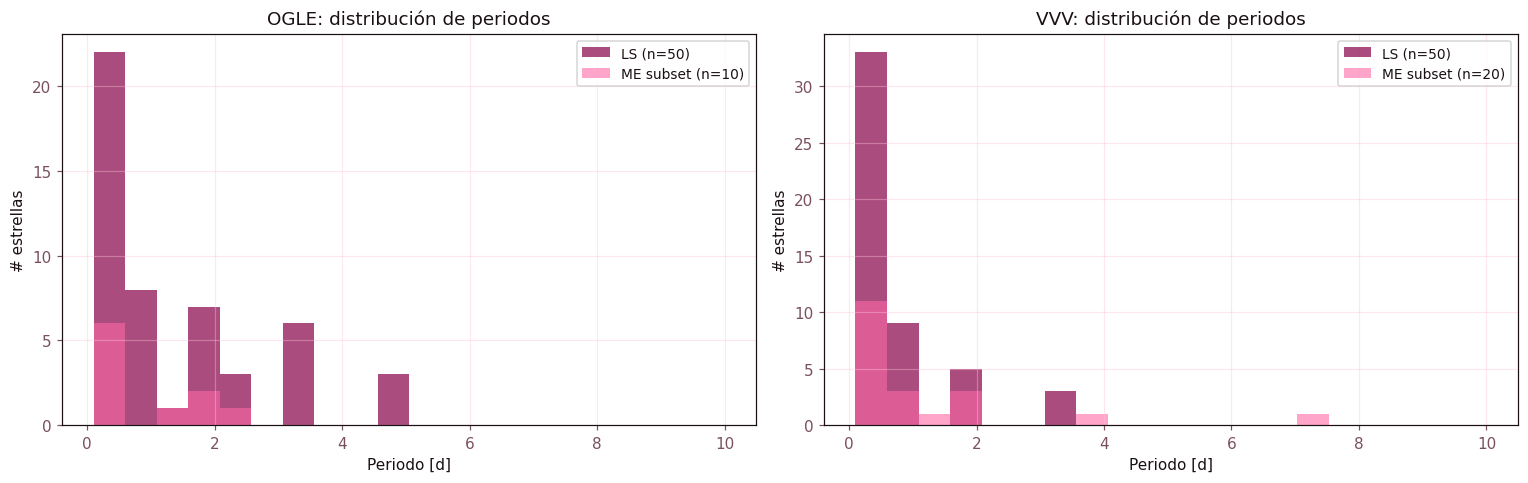

In [11]:
# (a) Distribución de periodos LS por survey
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, survey in zip(axes, ["OGLE", "VVV"]):
    sub = df[df["survey"] == survey]
    ax.hist(sub["period_ls"], bins=20, range=(P_MIN, P_MAX),
            color=PRIMARY, alpha=0.7, label=f"LS (n={len(sub)})")
    sub_me = sub[sub["has_minent"]]
    if len(sub_me):
        ax.hist(sub_me["period_me"], bins=20, range=(P_MIN, P_MAX),
                color=SECONDARY, alpha=0.6, label=f"ME subset (n={len(sub_me)})")
    ax.set_xlabel("Periodo [d]"); ax.set_ylabel("# estrellas")
    ax.set_title(f"{survey}: distribución de periodos")
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTDIR/"global_hist_periodos.png", dpi=200, bbox_inches="tight")
plt.show()

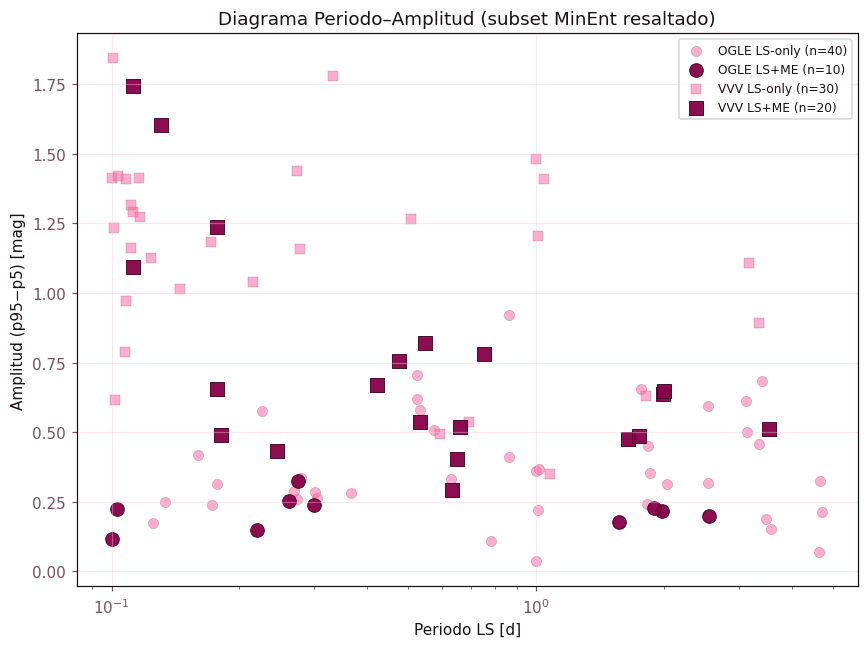

In [12]:
# (b) Periodo–Amplitud por survey, resaltando el subset MinEnt
fig, ax = plt.subplots(figsize=(8, 6))
markers = {"OGLE": "o", "VVV": "s"}
for survey in ["OGLE", "VVV"]:
    sub = df[df["survey"] == survey]
    not_me = sub[~sub["has_minent"]]
    is_me  = sub[ sub["has_minent"]]
    ax.scatter(not_me["period_ls"], not_me["amplitude"],
               marker=markers[survey], color=SECONDARY, s=45, alpha=0.55,
               edgecolor=MUTED, linewidth=0.3,
               label=f"{survey} LS-only (n={len(not_me)})")
    ax.scatter(is_me["period_ls"], is_me["amplitude"],
               marker=markers[survey], color=PRIMARY, s=80, alpha=0.95,
               edgecolor=DARK, linewidth=0.6,
               label=f"{survey} LS+ME (n={len(is_me)})")
ax.set_xscale("log")
ax.set_xlabel("Periodo LS [d]"); ax.set_ylabel("Amplitud (p95−p5) [mag]")
ax.set_title("Diagrama Periodo–Amplitud (subset MinEnt resaltado)")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(OUTDIR/"global_periodo_amplitud.png", dpi=200, bbox_inches="tight")
plt.show()

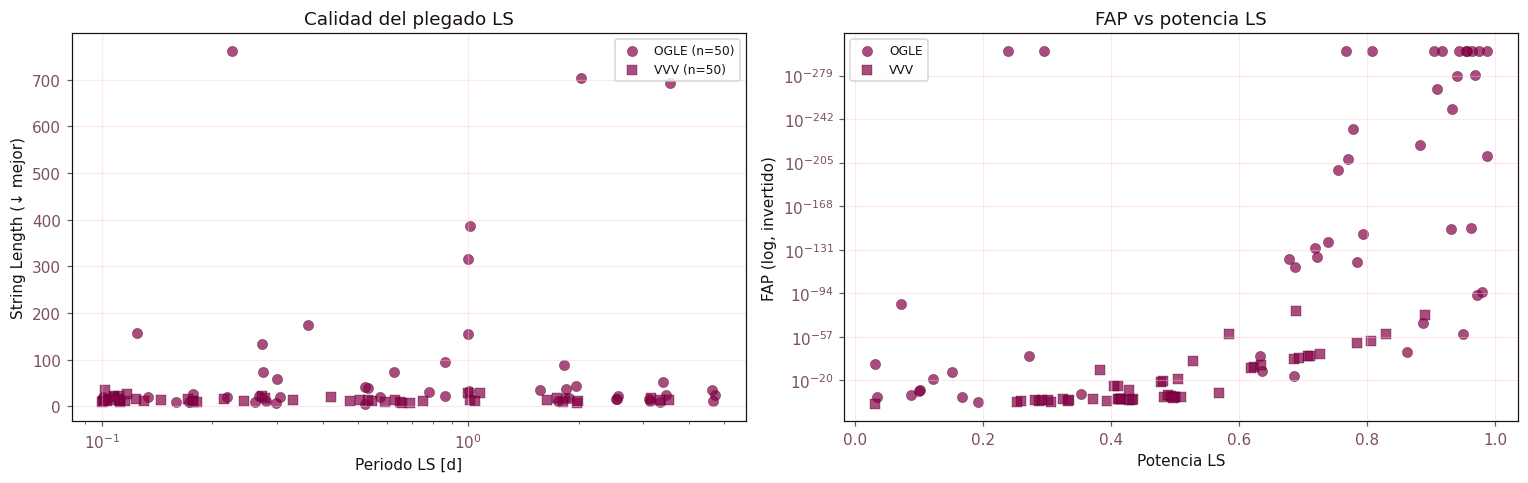

In [13]:
# (c) Métricas de calidad LS para las 100 + métricas ME para el subset
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for survey, mk in markers.items():
    sub = df[df["survey"] == survey]
    ax.scatter(sub["period_ls"], sub["sl_ls"], marker=mk, color=PRIMARY,
               s=45, alpha=0.7, edgecolor=DARK, linewidth=0.3,
               label=f"{survey} (n={len(sub)})")
ax.set_xscale("log")
ax.set_xlabel("Periodo LS [d]"); ax.set_ylabel("String Length (↓ mejor)")
ax.set_title("Calidad del plegado LS")
ax.legend(fontsize=8)

ax = axes[1]
for survey, mk in markers.items():
    sub = df[df["survey"] == survey]
    ax.scatter(sub["power_ls"], sub["fap_ls"].clip(lower=1e-300),
               marker=mk, color=PRIMARY, s=45, alpha=0.7,
               edgecolor=DARK, linewidth=0.3, label=f"{survey}")
ax.set_yscale("log"); ax.invert_yaxis()
ax.set_xlabel("Potencia LS"); ax.set_ylabel("FAP (log, invertido)")
ax.set_title("FAP vs potencia LS")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTDIR/"global_calidad.png", dpi=200, bbox_inches="tight")
plt.show()

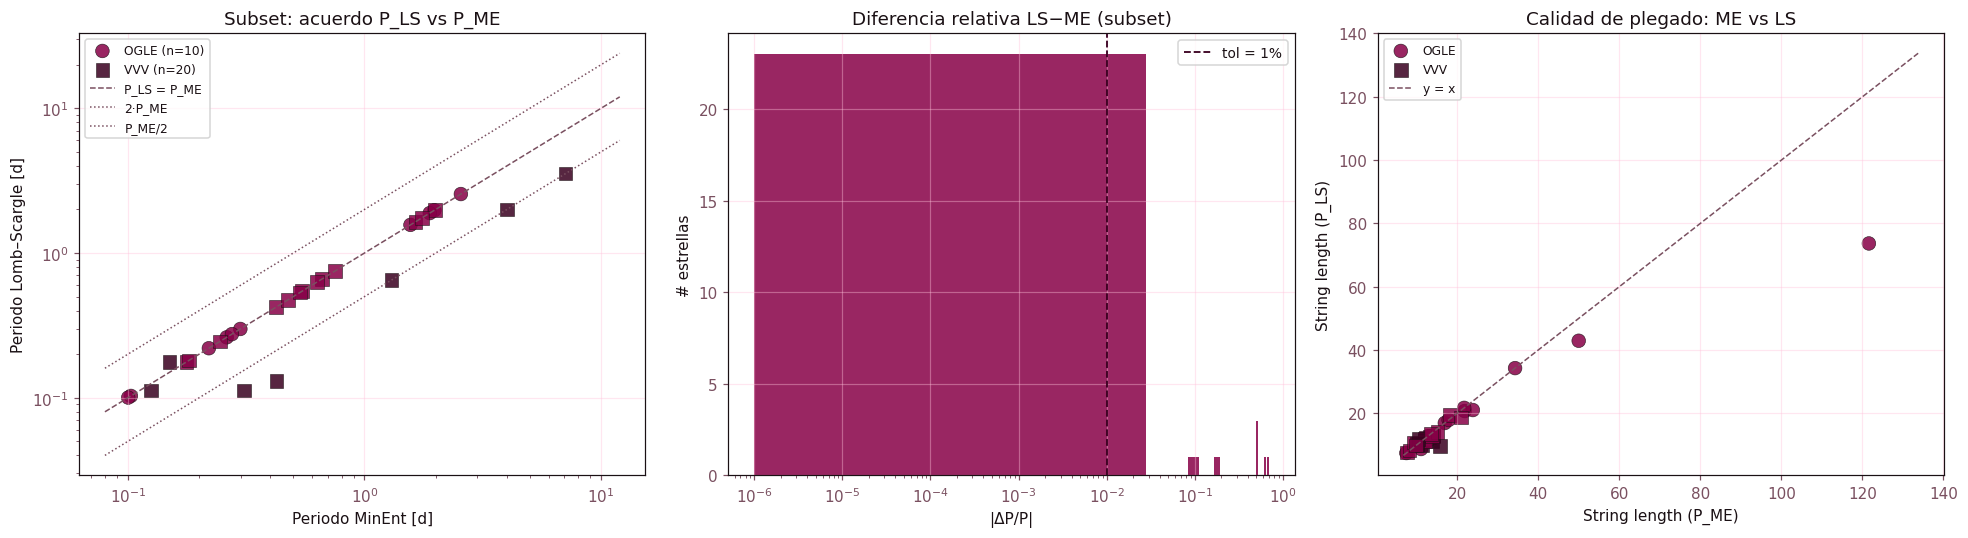

In [14]:
# (d) Subset: P_LS vs P_ME (log-log + armónicas) y string-length por método
sub_me = df[df["has_minent"]].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for survey, mk in markers.items():
    s = sub_me[sub_me["survey"] == survey]
    colors_ag = np.where(s["agree"], PRIMARY, DARK)
    ax.scatter(s["period_me"], s["period_ls"], marker=mk,
               c=colors_ag, s=80, alpha=0.85, edgecolor=INK, linewidth=0.4,
               label=f"{survey} (n={len(s)})")
lims = [P_MIN*0.8, P_MAX*1.2]
ax.plot(lims, lims, color=MUTED, ls="--", lw=1, label="P_LS = P_ME")
for k, lbl in [(2, "2·P_ME"), (0.5, "P_ME/2")]:
    ax.plot(lims, [k*v for v in lims], color=MUTED, ls=":", lw=1, label=lbl)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Periodo MinEnt [d]"); ax.set_ylabel("Periodo Lomb–Scargle [d]")
ax.set_title("Subset: acuerdo P_LS vs P_ME")
ax.legend(fontsize=8, loc="best")

ax = axes[1]
ax.hist(np.abs(sub_me["dP_rel"]).clip(lower=1e-6), bins=25,
        color=PRIMARY, alpha=0.85)
ax.axvline(AGREEMENT_TOL, color=DARK, ls="--", lw=1.2,
           label=f"tol = {AGREEMENT_TOL:.0%}")
ax.set_xscale("log")
ax.set_xlabel("|ΔP/P|"); ax.set_ylabel("# estrellas")
ax.set_title("Diferencia relativa LS−ME (subset)")
ax.legend(fontsize=9)

ax = axes[2]
for survey, mk in markers.items():
    s = sub_me[sub_me["survey"] == survey]
    colors_ag = np.where(s["agree"], PRIMARY, DARK)
    ax.scatter(s["sl_me"], s["sl_ls"], marker=mk, c=colors_ag,
               s=80, alpha=0.85, edgecolor=INK, linewidth=0.4,
               label=f"{survey}")
lims2 = [min(sub_me["sl_me"].min(), sub_me["sl_ls"].min())*0.9,
         max(sub_me["sl_me"].max(), sub_me["sl_ls"].max())*1.1]
ax.plot(lims2, lims2, color=MUTED, ls="--", lw=1, label="y = x")
ax.set_xlabel("String length (P_ME)"); ax.set_ylabel("String length (P_LS)")
ax.set_title("Calidad de plegado: ME vs LS")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTDIR/"global_subset_acuerdo.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Resumen estadístico

In [15]:
summary = df.groupby("survey").agg(
    n_total=("name","count"),
    n_minent=("has_minent","sum"),
    period_ls_median=("period_ls","median"),
    period_ls_p05=("period_ls", lambda s: s.quantile(0.05)),
    period_ls_p95=("period_ls", lambda s: s.quantile(0.95)),
    amplitude_median=("amplitude","median"),
    sl_ls_median=("sl_ls","median"),
    cov_ls_median=("cov_ls","median"),
    n_obs_median=("n_obs","median"),
).round(4)
summary.to_csv(OUTDIR/"resumen_por_survey.csv")
summary

,n_total,n_minent,period_ls_median,period_ls_p05,period_ls_p95,amplitude_median,sl_ls_median,cov_ls_median,n_obs_median
survey,,,,,,,,,
OGLE,50,10,0.8623,0.1286,4.1516,0.3023,24.4891,1.00,511.5
VVV,50,20,0.2757,0.1015,2.6385,1.0270,12.9159,0.95,84.5


In [16]:
# Resumen del subset con ambos métodos
subset_summary = sub_me.groupby("survey").agg(
    n=("name","count"),
    n_agree=("agree","sum"),
    frac_agree=("agree","mean"),
    period_ls_median=("period_ls","median"),
    period_me_median=("period_me","median"),
    abs_dPrel_median=("dP_rel", lambda s: np.median(np.abs(s))),
    sl_ls_median=("sl_ls","median"),
    sl_me_median=("sl_me","median"),
).round(4)
subset_summary.to_csv(OUTDIR/"resumen_subset.csv")
subset_summary

,n,n_agree,frac_agree,period_ls_median,period_me_median,abs_dPrel_median,sl_ls_median,sl_me_median
survey,,,,,,,,
OGLE,10,10,1.00,0.2871,0.2871,0.0,20.8667,21.7771
VVV,20,13,0.65,0.5391,0.5391,0.0,11.8815,12.6975


In [17]:
# Conteo de tipos de armónico en el subset
harm_counts = sub_me.groupby(["survey","harmonic"]).size().unstack(fill_value=0)
print("Conteo de relación armónica P_LS vs P_ME por survey:")
print(harm_counts)
harm_counts.to_csv(OUTDIR/"conteo_armonicos.csv")

Conteo de relación armónica P_LS vs P_ME por survey:
harmonic  sin armónico simple  ≈ P_ME  ≈ P_ME/2
survey                                         
OGLE                        0      10         0
VVV                         4      13         3


## 11. Insights globales (computados sobre el DataFrame)

In [18]:
def fmt(x, n=4):
    try:
        return f"{x:.{n}f}"
    except Exception:
        return str(x)

insights = []

# 1. Resumen LS por survey
for s in ["OGLE", "VVV"]:
    sub = df[df["survey"] == s]
    near_1d  = ((sub["period_ls"] > 0.995) & (sub["period_ls"] < 1.005)).mean()*100
    near_05d = ((sub["period_ls"] > 0.495) & (sub["period_ls"] < 0.505)).mean()*100
    near_pmax = (sub["period_ls"] > 0.95*P_MAX).mean()*100
    insights.append(
        f"- **{s} LS (n={len(sub)})**: P̃ = {fmt(sub['period_ls'].median())} d, "
        f"Ã = {fmt(sub['amplitude'].median(),2)} mag, SL̃ = {fmt(sub['sl_ls'].median(),2)}, "
        f"coṽ = {fmt(sub['cov_ls'].median(),2)}; "
        f"{near_1d:.0f}% en P≈1d, {near_05d:.0f}% en P≈0.5d, {near_pmax:.0f}% pegadas a P_MAX."
    )

# 2. FAP
high_conf = (df["fap_ls"] < 1e-10).mean()*100
insights.append(
    f"- **Significancia LS**: {high_conf:.0f}% de las {len(df)} estrellas tienen FAP < 1e-10. "
    f"OGLE = {(df[(df['survey']=='OGLE')]['fap_ls']<1e-10).mean()*100:.0f}%, "
    f"VVV = {(df[(df['survey']=='VVV')]['fap_ls']<1e-10).mean()*100:.0f}%."
)

# 3. Subset: acuerdo y string-length comparado
if len(sub_me):
    n_ag = int(sub_me["agree"].sum())
    insights.append(
        f"- **Acuerdo LS↔ME en el subset top-power** (|ΔP/P|<{AGREEMENT_TOL:.0%}): "
        f"{n_ag}/{len(sub_me)} ({100*n_ag/len(sub_me):.0f}%). "
        f"OGLE: {int(sub_me[sub_me['survey']=='OGLE']['agree'].sum())}/{(sub_me['survey']=='OGLE').sum()}, "
        f"VVV: {int(sub_me[sub_me['survey']=='VVV']['agree'].sum())}/{(sub_me['survey']=='VVV').sum()}."
    )
    sl_better_me = (sub_me["sl_me"] < sub_me["sl_ls"]).mean()*100
    insights.append(
        f"- **String length**: en {sl_better_me:.0f}% de las {len(sub_me)} del subset, MinEnt "
        f"produce un plegado *mejor* que LS (SL_ME < SL_LS). "
        f"Cuando MinEnt gana suele ser una curva no sinusoidal (RR Lyrae ab, eclipsantes)."
    )

    # 4. Armónicos
    harm_top = sub_me["harmonic"].value_counts()
    insights.append(
        "- **Tipos de relación armónica** (subset): " +
        ", ".join(f"{lbl} → {n}" for lbl, n in harm_top.items())
    )

    # 5. ¿El subset top-power tiene más amplitud / más N_obs?
    for s in ["OGLE", "VVV"]:
        full = df[df["survey"] == s]
        chosen = full[full["has_minent"]]
        rest = full[~full["has_minent"]]
        if len(chosen) and len(rest):
            insights.append(
                f"- **{s} subset vs resto**: amplitud mediana "
                f"{fmt(chosen['amplitude'].median(),2)} vs {fmt(rest['amplitude'].median(),2)} mag; "
                f"power_ls mediano {fmt(chosen['power_ls'].median(),3)} vs {fmt(rest['power_ls'].median(),3)}. "
                f"Confirma que ‘top-power’ selecciona estrellas más fuertemente periódicas."
            )

# 6. VVV vs OGLE cadencia
for s in ["OGLE", "VVV"]:
    sub = df[df["survey"] == s]
    insights.append(
        f"- **Cadencia {s}**: N_obs̃ = {int(sub['n_obs'].median())}, "
        f"baselinẽ = {fmt(sub['baseline_d'].median(),0)} d "
        f"(rango [{int(sub['n_obs'].min())}, {int(sub['n_obs'].max())}] obs)."
    )

print("\n".join(insights))

- **OGLE LS (n=50)**: P̃ = 0.8623 d, Ã = 0.30 mag, SL̃ = 24.49, coṽ = 1.00; 4% en P≈1d, 0% en P≈0.5d, 0% pegadas a P_MAX.
- **VVV LS (n=50)**: P̃ = 0.2757 d, Ã = 1.03 mag, SL̃ = 12.92, coṽ = 0.95; 2% en P≈1d, 0% en P≈0.5d, 0% pegadas a P_MAX.
- **Significancia LS**: 67% de las 100 estrellas tienen FAP < 1e-10. OGLE = 90%, VVV = 44%.
- **Acuerdo LS↔ME en el subset top-power** (|ΔP/P|<1%): 23/30 (77%). OGLE: 10/10, VVV: 13/20.
- **String length**: en 33% de las 30 del subset, MinEnt produce un plegado *mejor* que LS (SL_ME < SL_LS). Cuando MinEnt gana suele ser una curva no sinusoidal (RR Lyrae ab, eclipsantes).
- **Tipos de relación armónica** (subset): ≈ P_ME → 23, sin armónico simple → 4, ≈ P_ME/2 → 3
- **OGLE subset vs resto**: amplitud mediana 0.22 vs 0.33 mag; power_ls mediano 0.970 vs 0.720. Confirma que ‘top-power’ selecciona estrellas más fuertemente periódicas.
- **VVV subset vs resto**: amplitud mediana 0.64 vs 1.19 mag; power_ls mediano 0.660 vs 0.407. Confirma que ‘top-pow

## 12. Lectura cualitativa y cómo proseguir

**Qué nos dice este experimento**

- LS aplicado a las 100 estrellas da un periodo para *todas*, con FAP usable como filtro
  inicial de confianza. Para una muestra con cadencia OGLE (cientos de épocas, baseline de
  años) la mayoría cae en FAP < 1e-10; en VVV (decenas a cientos de épocas, baseline corto y
  estacional) la fracción confiable cae bastante.
- Tomar el **subset top-power** y verificar con **mínima entropía** es una estrategia barata
  para descubrir aliases sistemáticos: si el método más robusto-a-no-sinusoidal coincide,
  el periodo es muy creíble. Las discrepancias dominantes son `P_LS ≈ 2·P_ME` (típico en
  RR Lyrae ab si LS atrapa el primer armónico) y `P ≈ 1 d / 0.5 d` (aliasing diurno).
- El **string length** comparado entre métodos es un juez ortogonal: si SL_ME < SL_LS, la
  curva plegada con el periodo de MinEnt es más estrecha en mediana — eso es evidencia
  fuerte de que MinEnt encontró el periodo verdadero (típico para curvas asimétricas, donde
  LS suele dividirlo a la mitad).

**Próximos pasos**

1. **Aplicar MinEnt a las 100** para cuantificar la incidencia de alias en todo el sample, no
   sólo en el top-power. Cuello de botella: ~2–3 s/star ⇒ ~5 min total con joblib.
2. **Refinamiento local** alrededor del pico LS y el mínimo ME (Brent en ventana ±0.5 %)
   para reducir el error numérico al nivel de la cadencia.
3. **Penalizar aliases conocidos** (P ≈ 1, 0.5, 1/3 d) en ambos métodos antes de elegir el
   máximo, o usar **conditional entropy** (Graham+ 2013) que es naturalmente robusta a 1-day.
4. **Sumar PDM o BLS** como tercer juez; aceptar el periodo cuando ≥2 coincidan dentro de
   `|ΔP/P| < 1%`.
5. **Bootstrap de épocas** sobre el subset top-power para `σ_P` empírica.
6. Cruzar IDs con catálogos publicados (OGLE-IV `ident.dat`, VIRAC2 para VVV) para validar
   contra periodos *ground truth* y medir bias por método/survey.
7. Migrar las funciones a un módulo `period_pipeline.py` paralelizable con `joblib` y
   persistir resultados en Parquet para escalar a millones de curvas.